In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance
from scipy.stats import zscore

from sklearn.ensemble import (
    IsolationForest,
    RandomForestRegressor,
    GradientBoostingRegressor
)

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor
import matplotlib.patches as mpatches


In [2]:
# Loading the dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# EDA

In [3]:
# Display first 5 rows
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [4]:
df.shape

(141703, 41)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141703 entries, 0 to 141702
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       141703 non-null  object 
 1   location_name                 141703 non-null  object 
 2   latitude                      141703 non-null  float64
 3   longitude                     141703 non-null  float64
 4   timezone                      141703 non-null  object 
 5   last_updated_epoch            141703 non-null  int64  
 6   last_updated                  141703 non-null  object 
 7   temperature_celsius           141703 non-null  float64
 8   temperature_fahrenheit        141703 non-null  float64
 9   condition_text                141703 non-null  object 
 10  wind_mph                      141703 non-null  float64
 11  wind_kph                      141703 non-null  float64
 12  wind_degree                   141703 non-nul

In [6]:
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [7]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,141703.000000,141703.000000,1.417030e+05,141703.000000,141703.000000,141703.000000,141703.000000,141703.000000,141703.000000,141703.000000,...,141703.000000,141703.000000,141703.000000,141703.000000,141703.000000,141703.000000,141703.000000,141703.000000,141703.000000,141703.000000
mean,19.217298,21.937389,1.747385e+09,21.240746,70.235139,7.985144,12.854548,168.889741,1014.034819,29.943846,...,18.189074,451.856107,57.680120,14.845724,10.155373,23.892110,47.810536,1.688362,2.580326,49.858098
std,24.412662,65.783220,1.820291e+07,9.644740,17.360406,7.133232,11.476520,103.676036,10.203015,0.301239,...,13.698256,746.045423,30.477812,23.394650,34.922273,36.328714,147.427277,0.934262,2.424818,35.058899
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731661e+09,15.600000,60.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.200000,196.900000,38.000000,1.750000,1.110000,7.030000,9.850000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747386e+09,23.700000,74.700000,6.700000,10.800000,161.000000,1013.000000,29.930000,...,15.300000,288.600000,55.000000,5.735000,2.405000,14.000000,19.650000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.763105e+09,28.000000,82.300000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.100000,453.250000,73.000000,17.150000,8.140000,27.380000,40.900000,2.000000,3.000000,85.000000
max,64.150000,179.220000,1.778913e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [8]:
# Removing the impossible weather conditions 
df_cleaned = df[
    (df['temperature_celsius'] > -50) &
    (df['temperature_celsius'] < 60) &

    (df['wind_kph'] < 200) &

    (df['pressure_mb'] > 870) &
    (df['pressure_mb'] < 1100) &

    (df['humidity'] >= 0) &
    (df['humidity'] <= 100)
]

In [9]:
print("After cleaning shape:", df_cleaned.shape)

After cleaning shape: (141696, 41)


Here, after applying domain based filtering we can see that only 7 rows are removed, this shows that the dataset is already high quality and there was very few invalid or corrupt rows of data.

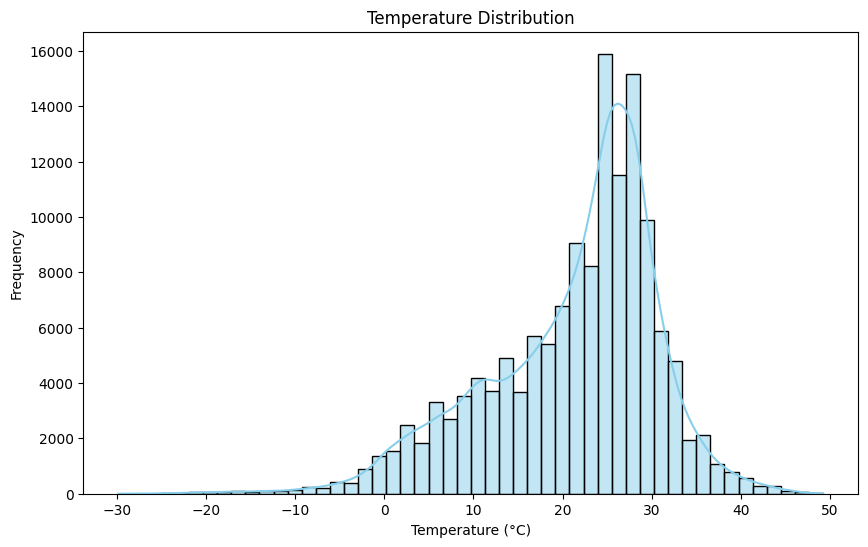

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_cleaned['temperature_celsius'],
    bins=50,
    kde=True,
    color='skyblue'
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

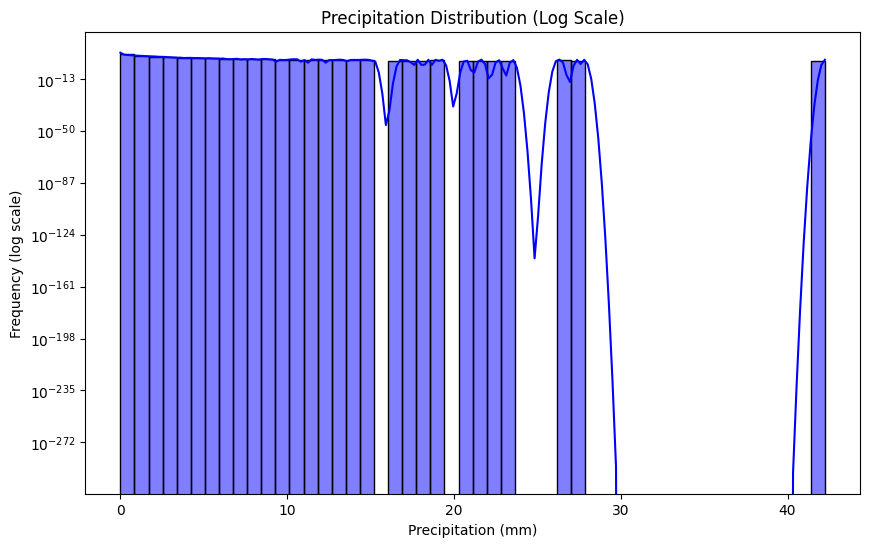

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_cleaned['precip_mm'],
    bins=50,
    kde=True,
    color='blue'
)

plt.yscale("log")  # important for skewed data

plt.title("Precipitation Distribution (Log Scale)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency (log scale)")

plt.show()


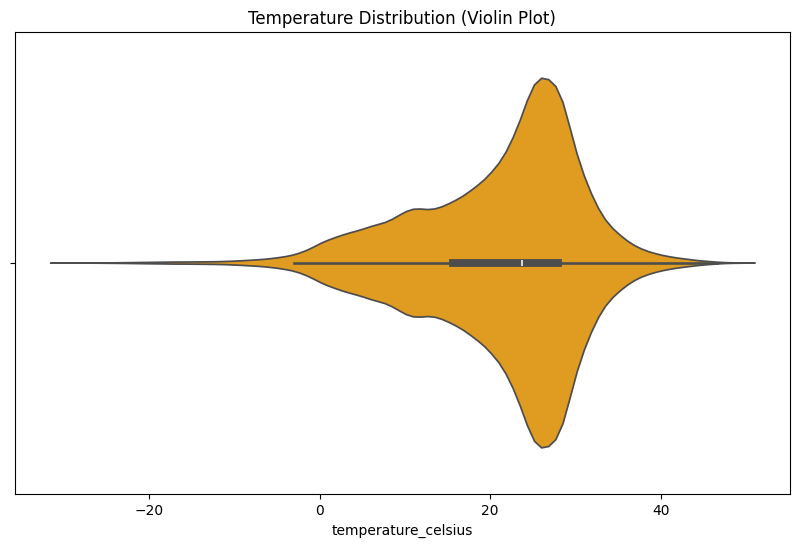

In [12]:
plt.figure(figsize=(10,6))

sns.violinplot(x=df_cleaned['temperature_celsius'], color='orange')

plt.title("Temperature Distribution (Violin Plot)")
plt.show()

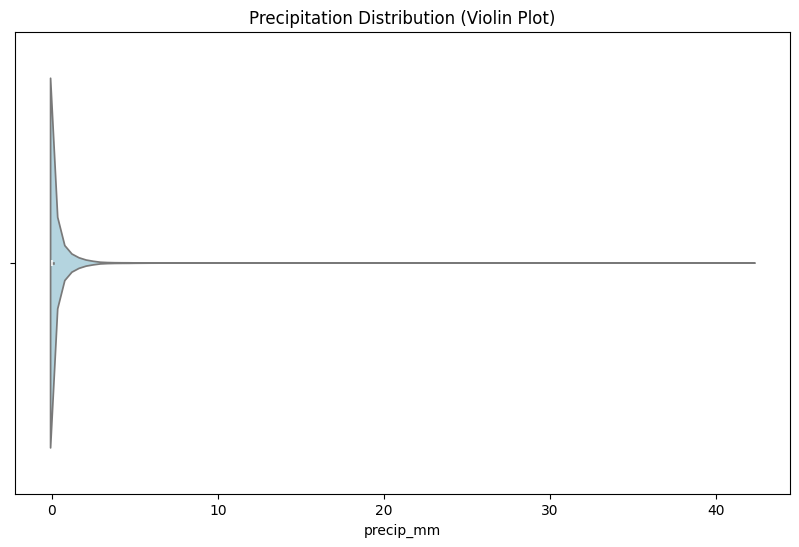

In [13]:
plt.figure(figsize=(10,6))

sns.violinplot(x=df_cleaned['precip_mm'], color='lightblue')

plt.title("Precipitation Distribution (Violin Plot)")
plt.show()

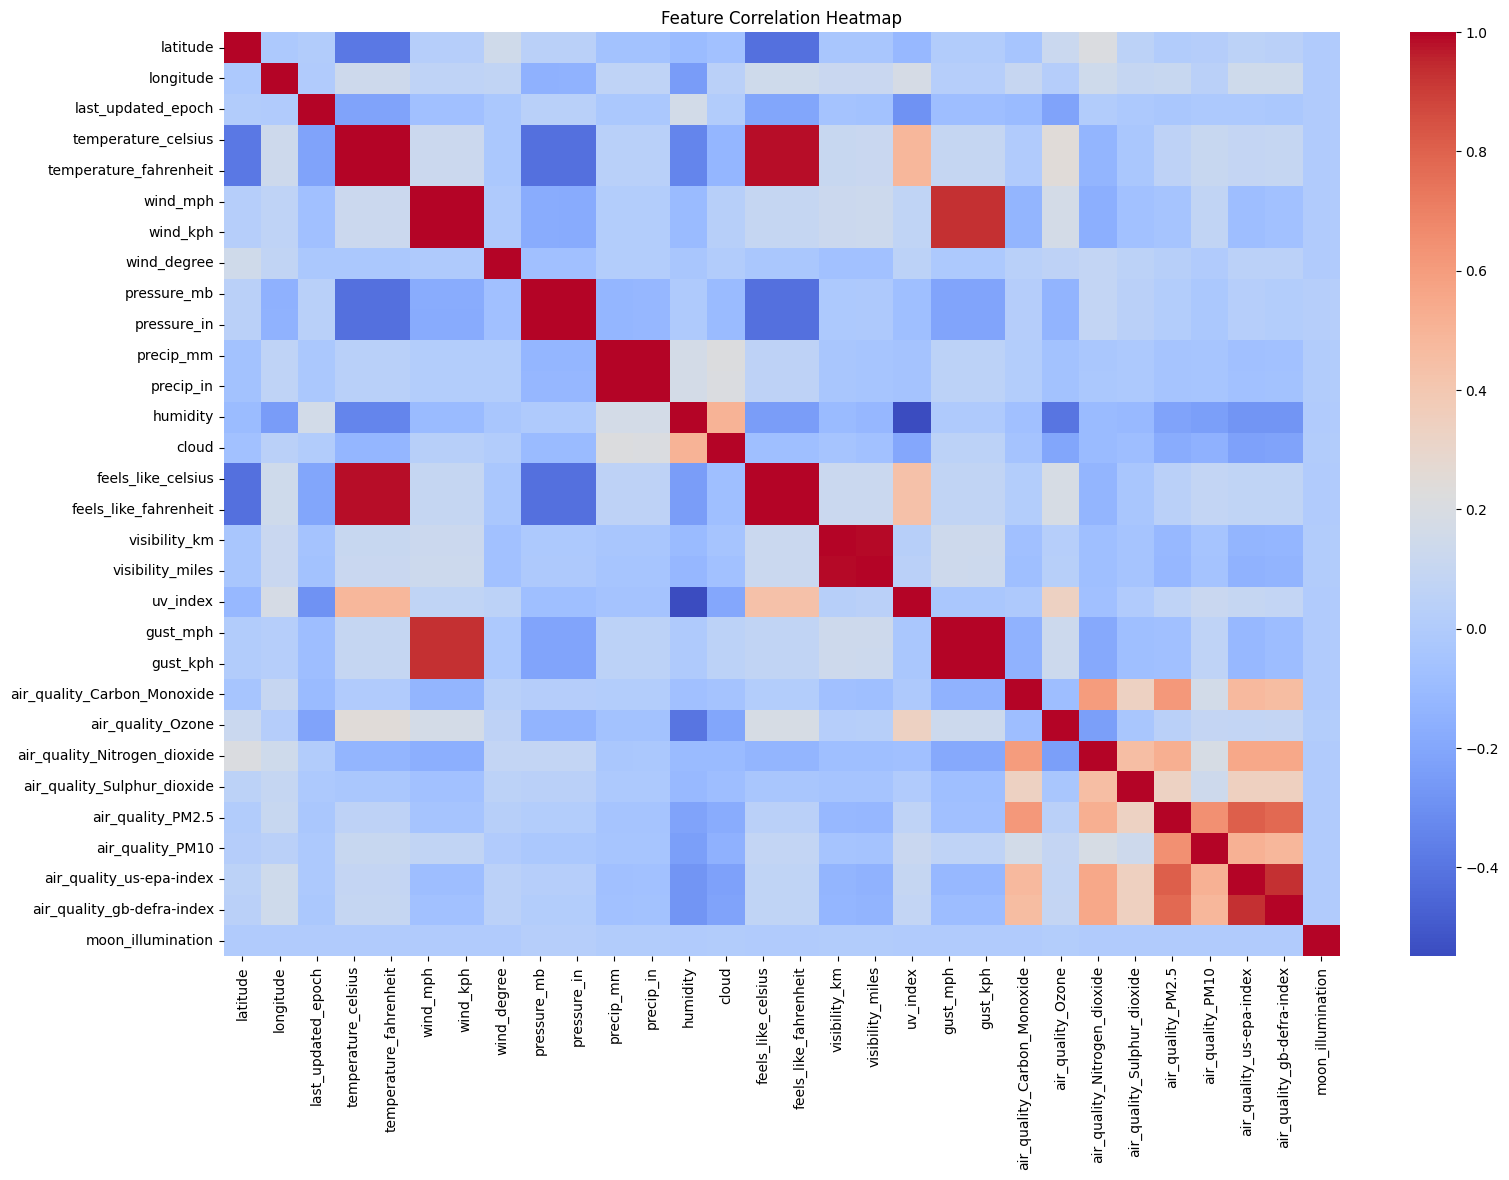

In [ ]:
# correlation heatmap

plt.figure(figsize=(18,12))

corr = df_cleaned.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Feature Correlation Heatmap")

plt.show()

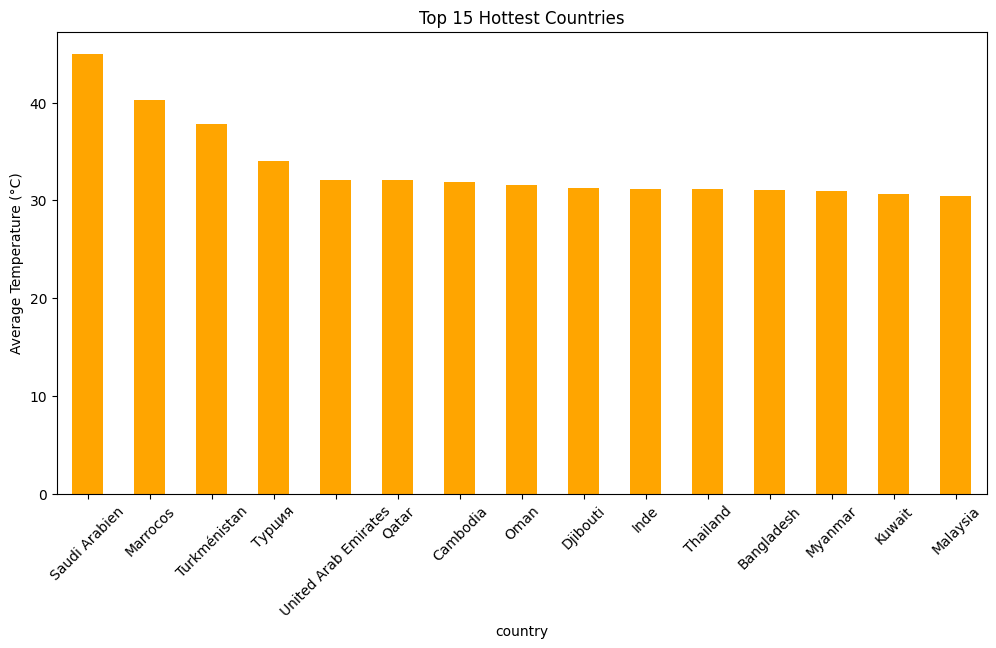

In [ ]:
top_countries = (
    df_cleaned.groupby('country')['temperature_celsius']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

top_countries.plot(kind='bar', color='orange')

plt.title("Top 15 Hottest Countries")
plt.ylabel("Average Temperature (°C)")

plt.xticks(rotation=45)

plt.show()

C:\Users\Harshitha GR\AppData\Local\Temp\ipykernel_1776\306474543.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['last_updated'] = pd.to_datetime(df_cleaned['last_updated'])


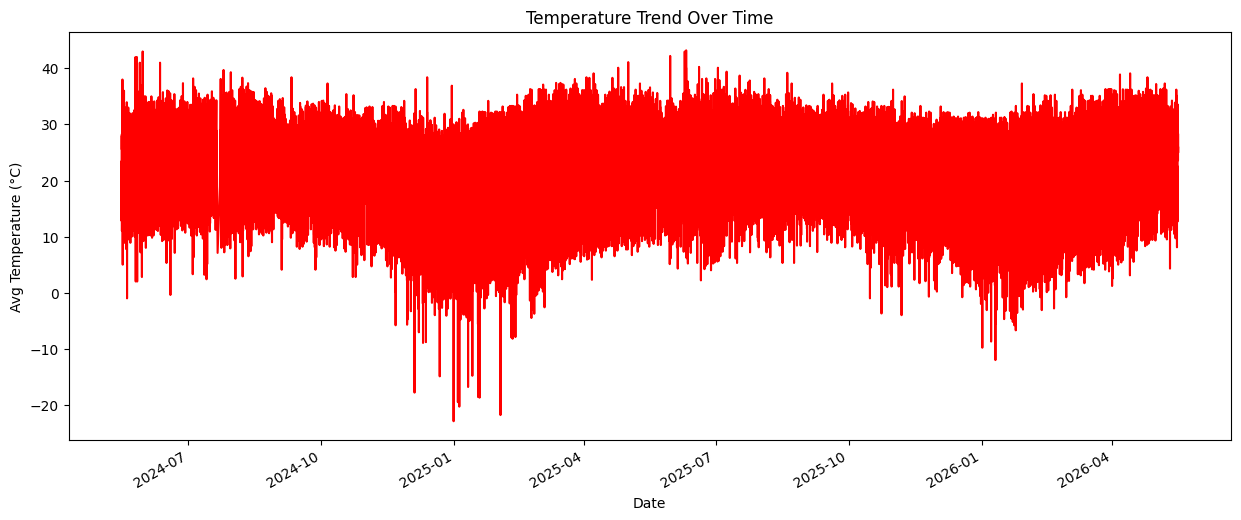

In [ ]:
df_cleaned['last_updated'] = pd.to_datetime(df_cleaned['last_updated'])

daily_temp = (
    df_cleaned.groupby('last_updated')['temperature_celsius']
    .mean()
    .sort_index()
)

plt.figure(figsize=(15,6))

daily_temp.plot(color='red')

plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Temperature (°C)")

plt.show()

C:\Users\Harshitha GR\AppData\Local\Temp\ipykernel_1776\251481120.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['last_updated'] = pd.to_datetime(df_cleaned['last_updated'])


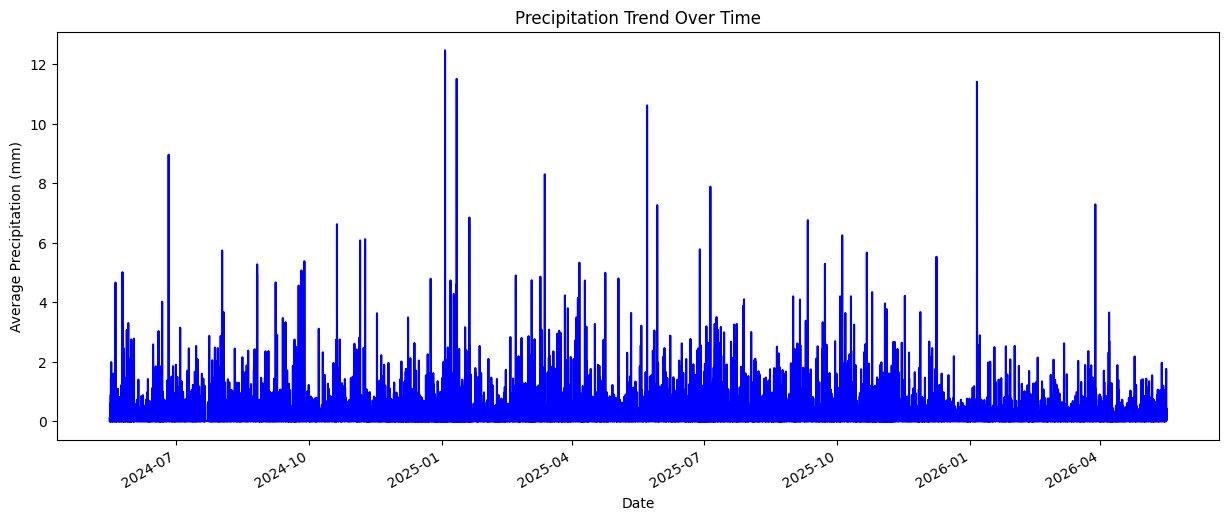

In [ ]:
df_cleaned['last_updated'] = pd.to_datetime(df_cleaned['last_updated'])

daily_precip = (
    df_cleaned.groupby('last_updated')['precip_mm']
    .mean()
    .sort_index()
)

plt.figure(figsize=(15,6))

daily_precip.plot(color='blue')

plt.title("Precipitation Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Precipitation (mm)")

plt.show()

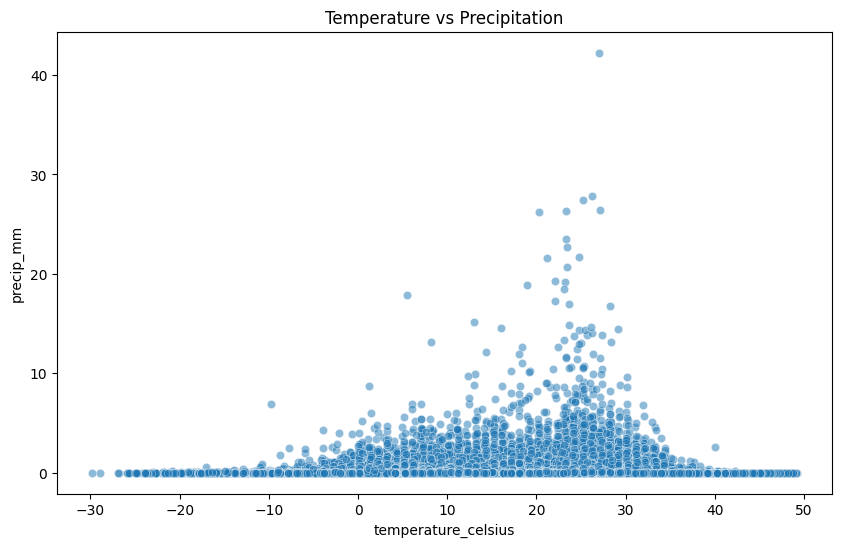

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='temperature_celsius',
    y='precip_mm',
    data=df_cleaned,
    alpha=0.5
)

plt.title("Temperature vs Precipitation")

plt.show()

# Time series model

In [27]:
df_cleaned['last_updated'] = pd.to_datetime(df_cleaned['last_updated'])

ts = df_cleaned.groupby('last_updated')['temperature_celsius'].mean()

ts = ts.sort_index()

train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (18776,)
Test shape: (4695,)


C:\Users\Harshitha GR\AppData\Local\Temp\ipykernel_1776\3915408936.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['last_updated'] = pd.to_datetime(df_cleaned['last_updated'])


In [30]:
# Naive Model
forecast_naive = np.repeat(train.iloc[-1], len(test))

mae_naive = mean_absolute_error(test, forecast_naive)
rmse_naive = np.sqrt(mean_squared_error(test, forecast_naive))
r2_naive = r2_score(test, forecast_naive)

print("Naive Model Performance:")
print("MAE :", mae_naive)
print("RMSE:", rmse_naive)
print("R2  :", r2_naive)

Naive Model Performance:
MAE : 6.633181422768833
RMSE: 8.501035292936479
R2  : -0.20557910908792043


In [ ]:
# seasonal naive model

season_length = 7

forecast_seasonal = train.iloc[-season_length:].values

forecast_seasonal = np.resize(forecast_seasonal, len(test))

mae_seasonal = mean_absolute_error(test, forecast_seasonal)
rmse_seasonal = np.sqrt(mean_squared_error(test, forecast_seasonal))
r2_seasonal = r2_score(test, forecast_seasonal)

print("Seasonal Naive Performance:")
print("MAE :", mae_seasonal)
print("RMSE:", rmse_seasonal)
print("R2  :", r2_seasonal)

Seasonal Naive Performance:
MAE : 6.594846323945535
RMSE: 8.384853297954797
R2  : -0.1728514589083634


In [34]:
# rolling mean

window = 7

rolling_mean = train.rolling(window=window).mean()

forecast_roll = np.repeat(rolling_mean.iloc[-1], len(test))

mae_roll = mean_absolute_error(test, forecast_roll)
rmse_roll = np.sqrt(mean_squared_error(test, forecast_roll))
r2_roll = r2_score(test, forecast_roll)

print("Rolling Mean Performance:")
print("MAE :", mae_roll)
print("RMSE:", rmse_roll)
print("R2  :", r2_roll)

Rolling Mean Performance:
MAE : 6.195594654574991
RMSE: 7.944258164643781
R2  : -0.052831264865291105


In [36]:
results = pd.DataFrame({
    "Model": [
        "Naive (Last Value)",
        "Seasonal Naive",
        "Rolling Mean"
    ],
    "MAE": [
        mae_naive,
        mae_seasonal,
        mae_roll
    ],
    "RMSE": [
        rmse_naive,
        rmse_seasonal,
        rmse_roll
    ],
    "R2": [
        r2_naive,
        r2_seasonal,
        r2_roll
    ]
})

results

,Model,MAE,RMSE,R2
0,Naive (Last Value),6.633181,8.501035,-0.205579
1,Seasonal Naive,6.594846,8.384853,-0.172851
2,Rolling Mean,6.195595,7.944258,-0.052831


All baseline forecasting models (Naive, Seasonal Naive and Rolling Mean) resulted in negative R² scores, indicating that simple persistence based forecasting methods are insufficient for capturing the complex temporal patterns present in global weather data. Among the baseline approaches, the Rolling Mean model achieved the best performance with the lowest MAE and RMSE values, suggesting that short term temporal smoothing provides a modest improvement in forecasting accuracy.

# Advanced anamoly detection using z score, IQR and Isolation forest

In [ ]:
# compute z-score for temperature
df_cleaned['temp_zscore'] = zscore(df_cleaned['temperature_celsius'])

# anomalies
z_anomalies = df_cleaned[abs(df_cleaned['temp_zscore']) > 3]

print("Z-score anomalies:", z_anomalies.shape)
z_anomalies.head()

Z-score anomalies: (960, 42)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,temp_zscore
29235,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1728898200,2024-10-14 17:30:00,-8.4,16.9,Sunny,...,4.255,1,1,07:10 AM,06:06 PM,04:51 PM,02:21 AM,Waxing Gibbous,83,-3.073605
29820,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1729157400,2024-10-17 17:30:00,-7.9,17.8,Sunny,...,7.215,1,1,07:15 AM,06:00 PM,05:45 PM,06:40 AM,Full Moon,100,-3.021756
30600,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1729502100,2024-10-21 17:15:00,-10.4,13.2,Sunny,...,7.585,1,1,07:21 AM,05:53 PM,07:56 PM,12:27 PM,Waning Gibbous,83,-3.280998
32884,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1730538900,2024-11-02 17:15:00,-11.0,12.2,Partly Cloudy,...,12.950,1,1,07:39 AM,05:33 PM,08:26 AM,05:27 PM,Waxing Crescent,0,-3.343216
33079,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1730624400,2024-11-03 17:00:00,-12.1,10.3,Sunny,...,7.030,1,1,07:41 AM,05:31 PM,09:38 AM,05:53 PM,Waxing Crescent,2,-3.457282


In [51]:
Q1 = df_cleaned['temperature_celsius'].quantile(0.25)
Q3 = df_cleaned['temperature_celsius'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_anomalies = df_cleaned[
    (df_cleaned['temperature_celsius'] < lower) |
    (df_cleaned['temperature_celsius'] > upper)
]

print("IQR anomalies:", iqr_anomalies.shape)

IQR anomalies: (1988, 42)


In [ ]:
features = [
    'temperature_celsius',
    'wind_kph',
    'pressure_mb',
    'humidity',
    'precip_mm'
]

iso = IsolationForest(contamination=0.01, random_state=42)

df_cleaned['anomaly'] = iso.fit_predict(df_cleaned[features])

# -1 = anomaly, 1 = normal
iso_anomalies = df_cleaned[df_cleaned['anomaly'] == -1]

print("Isolation Forest anomalies:", iso_anomalies.shape)

Isolation Forest anomalies: (1417, 43)


In [54]:
df_cleaned['z_anomaly'] = (abs(df_cleaned['temp_zscore']) > 3).astype(int)

df_cleaned['iqr_anomaly'] = (
    (df_cleaned['temperature_celsius'] < lower) |
    (df_cleaned['temperature_celsius'] > upper)
).astype(int)

df_cleaned['iso_anomaly'] = (df_cleaned['anomaly'] == -1).astype(int)

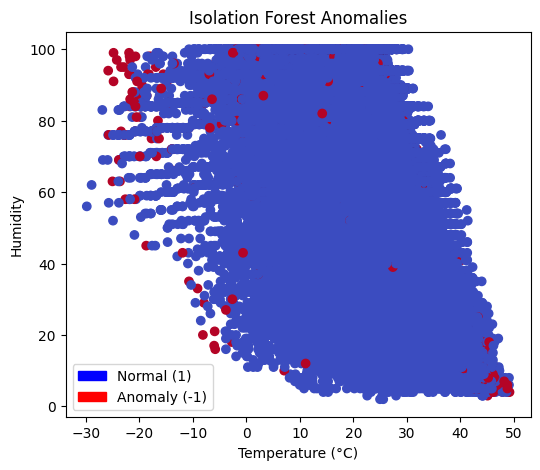

In [ ]:
plt.figure(figsize=(6,5))

scatter = plt.scatter(
    df_cleaned['temperature_celsius'],
    df_cleaned['humidity'],
    c=df_cleaned['iso_anomaly'],
    cmap='coolwarm'
)

# Create custom legend labels
normal_patch = mpatches.Patch(color='blue', label='Normal (1)')
anomaly_patch = mpatches.Patch(color='red', label='Anomaly (-1)')

plt.legend(handles=[normal_patch, anomaly_patch])

plt.title("Isolation Forest Anomalies")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity")

plt.show()

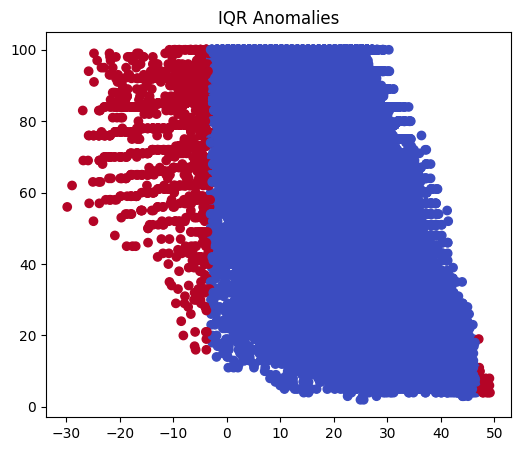

In [56]:
plt.figure(figsize=(6,5))

plt.scatter(
    df_cleaned['temperature_celsius'],
    df_cleaned['humidity'],
    c=df_cleaned['iqr_anomaly'],
    cmap='coolwarm'
)

plt.title("IQR Anomalies")
plt.show()

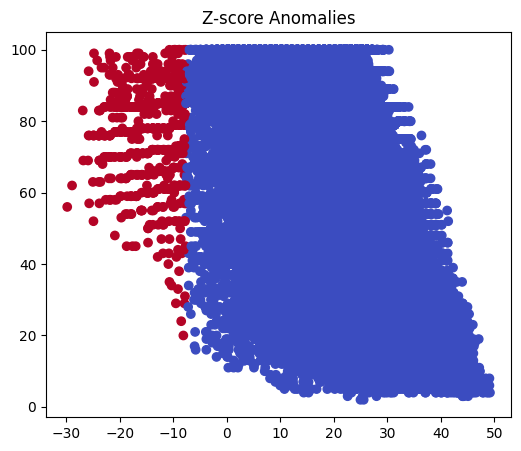

In [57]:
plt.figure(figsize=(6,5))

plt.scatter(
    df_cleaned['temperature_celsius'],
    df_cleaned['humidity'],
    c=df_cleaned['z_anomaly'],
    cmap='coolwarm'
)

plt.title("Z-score Anomalies")
plt.show()

Different anomaly detection methods highlight different subsets of unusual data points. While IQR and Z-score methods focus on univariate statistical deviations, Isolation Forest captures multivariate relationships, making it more suitable for complex weather datasets.

# Forecasting with multiple models

This section focuses on advanced time series forecasting using multiple statistical and machine learning models. Different forecasting approaches including ARIMA, Prophet, Random Forest, Gradient Boosting, and XGBoost are implemented and compared to evaluate their ability to capture temporal weather patterns. Model performance is assessed using MAE, RMSE, and R² metrics. Finally, an ensemble forecasting model is created by combining predictions from multiple models to improve overall forecasting robustness and accuracy.

In [ ]:
# ARIMA model 

arima_model = ARIMA(train, order=(5,1,0))

arima_fit = arima_model.fit()

forecast_arima = arima_fit.forecast(steps=len(test))

print(forecast_arima[:5])

mae_arima = mean_absolute_error(test, forecast_arima)

rmse_arima = np.sqrt(
    mean_squared_error(test, forecast_arima)
)

r2_arima = r2_score(test, forecast_arima)

print("ARIMA Performance:")
print("MAE :", mae_arima)
print("RMSE:", rmse_arima)
print("R2  :", r2_arima)


d:\Anaconda3\envs\dl_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda3\envs\dl_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda3\envs\dl_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda3\envs\dl_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\A

18776    22.273697
18777    22.274361
18778    22.462999
18779    22.217248
18780    22.353409
Name: predicted_mean, dtype: float64
ARIMA Performance:
MAE : 6.354954158452334
RMSE: 8.15735598164752
R2  : -0.11007137902017061


In [ ]:
# prophet model

prophet_df = ts.reset_index()

prophet_df.columns = ['ds', 'y']

train_p = prophet_df.iloc[:train_size]
test_p = prophet_df.iloc[train_size:]

prophet_model = Prophet()

prophet_model.fit(train_p)

future = prophet_model.make_future_dataframe(
    periods=len(test_p)
)

forecast_prophet_full = prophet_model.predict(future)

forecast_prophet = forecast_prophet_full['yhat'].iloc[-len(test_p):].values


mae_prophet = mean_absolute_error(
    test_p['y'],
    forecast_prophet
)

rmse_prophet = np.sqrt(
    mean_squared_error(test_p['y'], forecast_prophet)
)

r2_prophet = r2_score(
    test_p['y'],
    forecast_prophet
)

print("Prophet Performance:")
print("MAE :", mae_prophet)
print("RMSE:", rmse_prophet)
print("R2  :", r2_prophet)

Importing plotly failed. Interactive plots will not work.
15:05:06 - cmdstanpy - INFO - Chain [1] start processing
15:05:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet Performance:
MAE : 116.6714770430429
RMSE: 135.5028947155599
R2  : -305.30156894254816


In [ ]:
# XGBOOST 

xgb_df = ts.reset_index()

xgb_df.columns = ['date', 'temp']

# lag features
xgb_df['lag1'] = xgb_df['temp'].shift(1)

xgb_df['lag7'] = xgb_df['temp'].shift(7)

xgb_df['rolling_mean_7'] = (
    xgb_df['temp']
    .rolling(window=7)
    .mean()
)

xgb_df = xgb_df.dropna()

X = xgb_df[['lag1', 'lag7', 'rolling_mean_7']]

y = xgb_df['temp']

split = int(len(xgb_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

forecast_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(
    y_test,
    forecast_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, forecast_xgb)
)

r2_xgb = r2_score(
    y_test,
    forecast_xgb
)

print("XGBoost Performance:")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

XGBoost Performance:
MAE : 4.811903457696579
RMSE: 6.29579374464006
R2  : 0.33899955495665257


In [ ]:

# RANDOM FOREST 

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

forecast_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(
    y_test,
    forecast_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, forecast_rf)
)

r2_rf = r2_score(
    y_test,
    forecast_rf
)

print("Random Forest Performance:")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest Performance:
MAE : 5.061595027998525
RMSE: 6.574182840662311
R2  : 0.2792505405206238


In [ ]:

# GRADIENT BOOSTING 

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

forecast_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(
    y_test,
    forecast_gb
)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, forecast_gb)
)

r2_gb = r2_score(
    y_test,
    forecast_gb
)

print("Gradient Boosting Performance:")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R2  :", r2_gb)

Gradient Boosting Performance:
MAE : 4.780249330588332
RMSE: 6.2628544368757595
R2  : 0.34589810994960024


In [51]:
comparison = pd.DataFrame({
    "Model": [
        "ARIMA",
        "Prophet",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mae_arima,
        mae_prophet,
        mae_rf,
        mae_gb,
        mae_xgb
    ],
    "RMSE": [
        rmse_arima,
        rmse_prophet,
        rmse_rf,
        rmse_gb,
        rmse_xgb
    ],
    "R2": [
        r2_arima,
        r2_prophet,
        r2_rf,
        r2_gb,
        r2_xgb
    ]
})

comparison.sort_values("RMSE")

,Model,MAE,RMSE,R2
3,Gradient Boosting,4.780249,6.262854,0.345898
4,XGBoost,4.811903,6.295794,0.339000
2,Random Forest,5.061595,6.574183,0.279251
0,ARIMA,6.354954,8.157356,-0.110071
1,Prophet,116.671477,135.502895,-305.301569


## Model Comparison and Key Insights

From the results, it is evident that tree based machine learning models significantly outperform traditional statistical forecasting methods. Gradient Boosting achieved the best overall performance with the lowest MAE and RMSE values and the highest R² score, closely followed by XGBoost. Random Forest also performed reasonably well but was slightly less accurate compared to boosting-based approaches.

In contrast, ARIMA showed limited effectiveness on this dataset, resulting in negative R² values. This indicates that classical time series assumptions such as stationarity and linear temporal dependencies are not well-suited for this highly complex, multi-region weather dataset. Similarly, Prophet performed poorly due to the irregular and globally aggregated nature of the data, which violates its assumption of a single, consistent time series with clear seasonality patterns.

In [ ]:
# Ensemble model

min_len = min(
    len(forecast_rf),
    len(forecast_gb),
    len(forecast_xgb)
)

ensemble_ml = (
    forecast_rf[:min_len] +
    forecast_gb[:min_len] +
    forecast_xgb[:min_len]
) / 3

In [53]:
ensemble_true = y_test.iloc[:min_len]

mae_ensemble = mean_absolute_error(
    ensemble_true,
    ensemble_ml
)

rmse_ensemble = np.sqrt(
    mean_squared_error(
        ensemble_true,
        ensemble_ml
    )
)

r2_ensemble = r2_score(
    ensemble_true,
    ensemble_ml
)

print("Ensemble Performance:")
print("MAE :", mae_ensemble)
print("RMSE:", rmse_ensemble)
print("R2  :", r2_ensemble)

Ensemble Performance:
MAE : 4.817319721290849
RMSE: 6.285607805891082
R2  : 0.3411366845213816


The Ensemble model, which combines predictions from multiple machine learning models, provided stable and balanced performance. However, it did not significantly outperform Gradient Boosting, suggesting that Gradient Boosting already captures most of the underlying predictive structure in the data.

Overall, these results highlight that machine learning based ensemble methods are more effective for modeling complex, nonlinear and high dimensional weather data compared to traditional statistical forecasting techniques. The analysis also demonstrates the importance of model selection based on data characteristics rather than relying on a single forecasting approach.

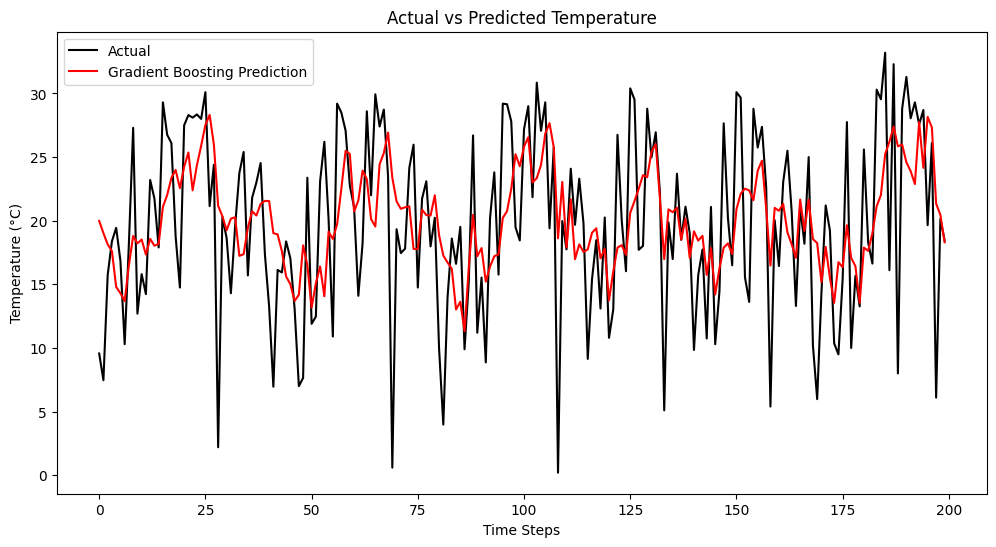

In [54]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual", color="black")
plt.plot(forecast_gb[:200], label="Gradient Boosting Prediction", color="red")

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time Steps")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

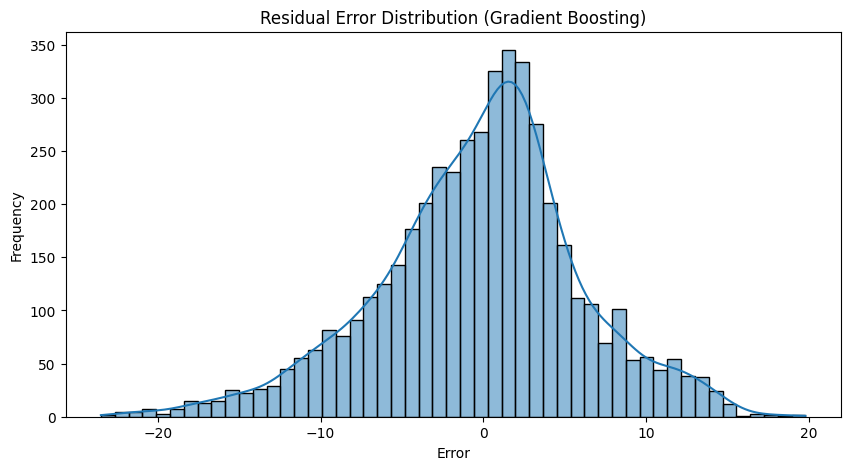

In [56]:
errors = y_test.values - forecast_gb

plt.figure(figsize=(10,5))

sns.histplot(errors, kde=True)

plt.title("Residual Error Distribution (Gradient Boosting)")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

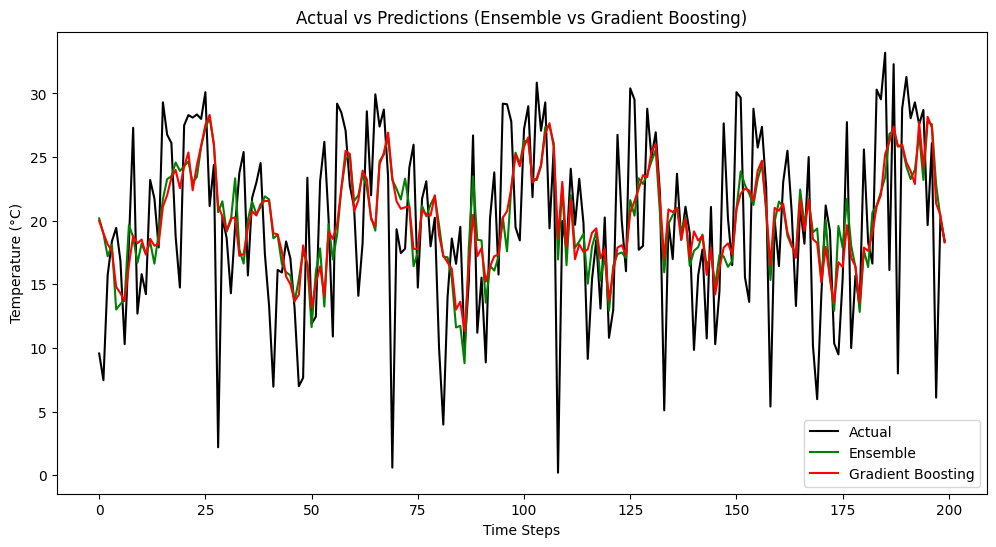

In [60]:
plt.figure(figsize=(12,6))

# actual values
plt.plot(y_test.values[:200], label="Actual", color="black")

# predictions
plt.plot(ensemble_ml[:200], label="Ensemble", color="green")
plt.plot(forecast_gb[:200], label="Gradient Boosting", color="red")

plt.title("Actual vs Predictions (Ensemble vs Gradient Boosting)")
plt.xlabel("Time Steps")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

# Unique analysis

### 1. Climate Analysis

C:\Users\Harshitha GR\AppData\Local\Temp\ipykernel_1776\2193476826.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['last_updated'] = pd.to_datetime(df_cleaned['last_updated'])
C:\Users\Harshitha GR\AppData\Local\Temp\ipykernel_1776\2193476826.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key='last_updated', freq='M'))['temperature_celsius']


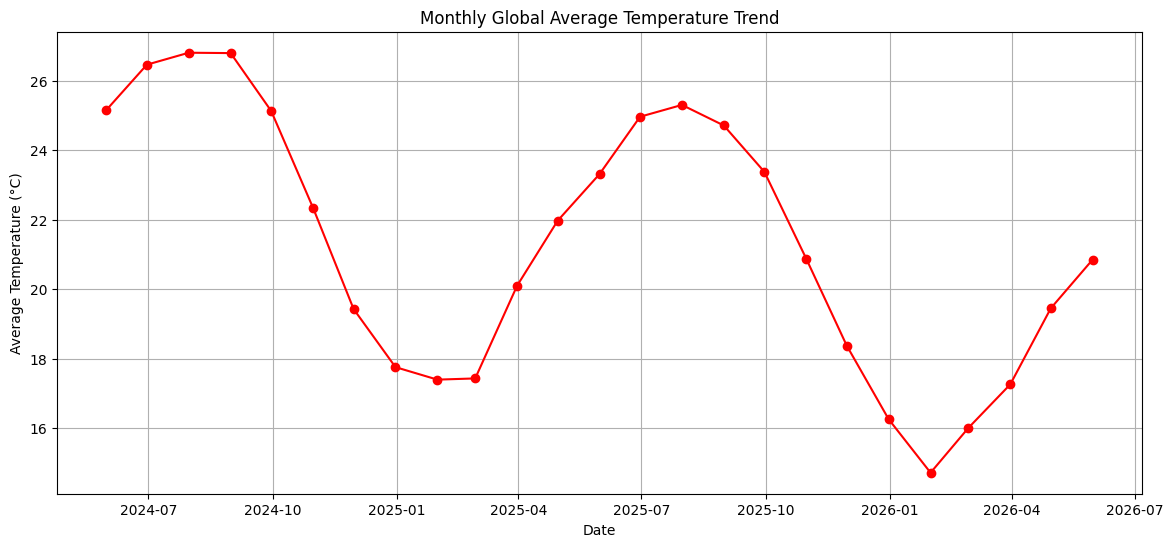

In [ ]:
df_cleaned['last_updated'] = pd.to_datetime(df_cleaned['last_updated'])

monthly_climate = (
    df_cleaned
    .groupby(pd.Grouper(key='last_updated', freq='M'))['temperature_celsius']
    .mean()
    .reset_index()
    .sort_values('last_updated')
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_climate['last_updated'],
    monthly_climate['temperature_celsius'],
    marker='o',
    color='red'
)

plt.title("Monthly Global Average Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)

plt.show()

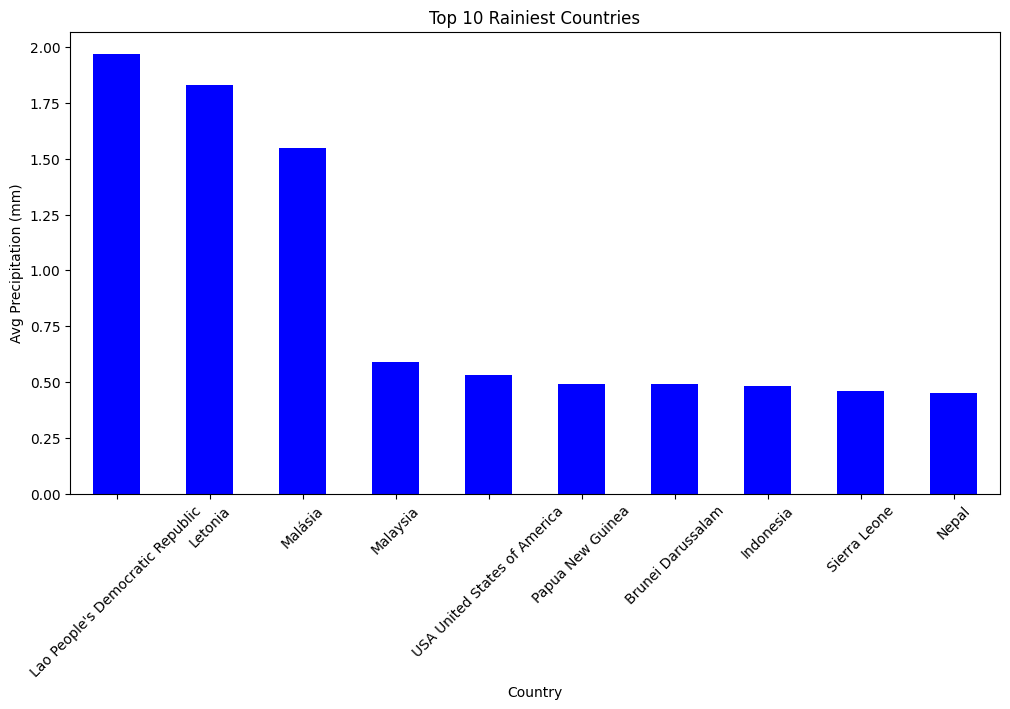

In [65]:
rain_countries = (
    df_cleaned.groupby('country')['precip_mm']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

rain_countries.plot(kind='bar', color='blue')

plt.title("Top 10 Rainiest Countries")
plt.xlabel("Country")
plt.ylabel("Avg Precipitation (mm)")

plt.xticks(rotation=45)

plt.show()

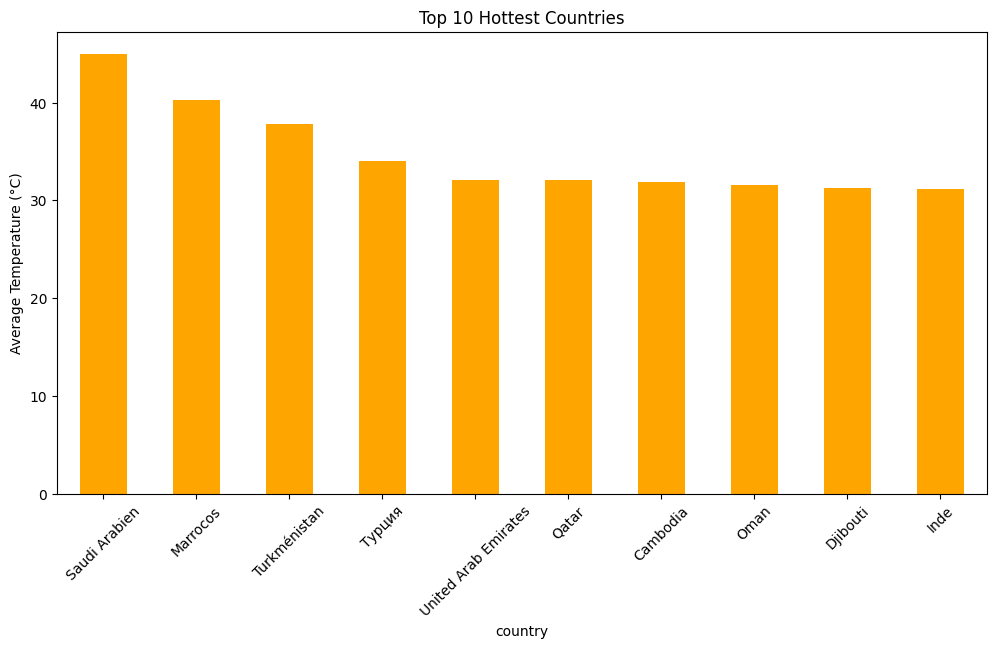

In [67]:
top_countries = (
    df_cleaned.groupby('country')['temperature_celsius']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_countries.plot(kind='bar', color='orange')

plt.title("Top 10 Hottest Countries")
plt.ylabel("Average Temperature (°C)")

plt.xticks(rotation=45)

plt.show()

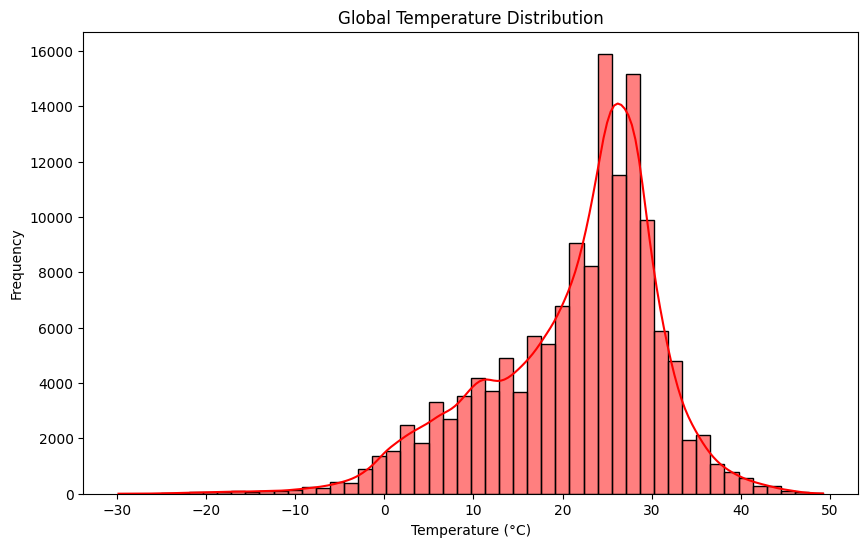

In [64]:
plt.figure(figsize=(10,6))

sns.histplot(df_cleaned['temperature_celsius'], bins=50, kde=True, color='red')

plt.title("Global Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

### 2. Environmental Impact

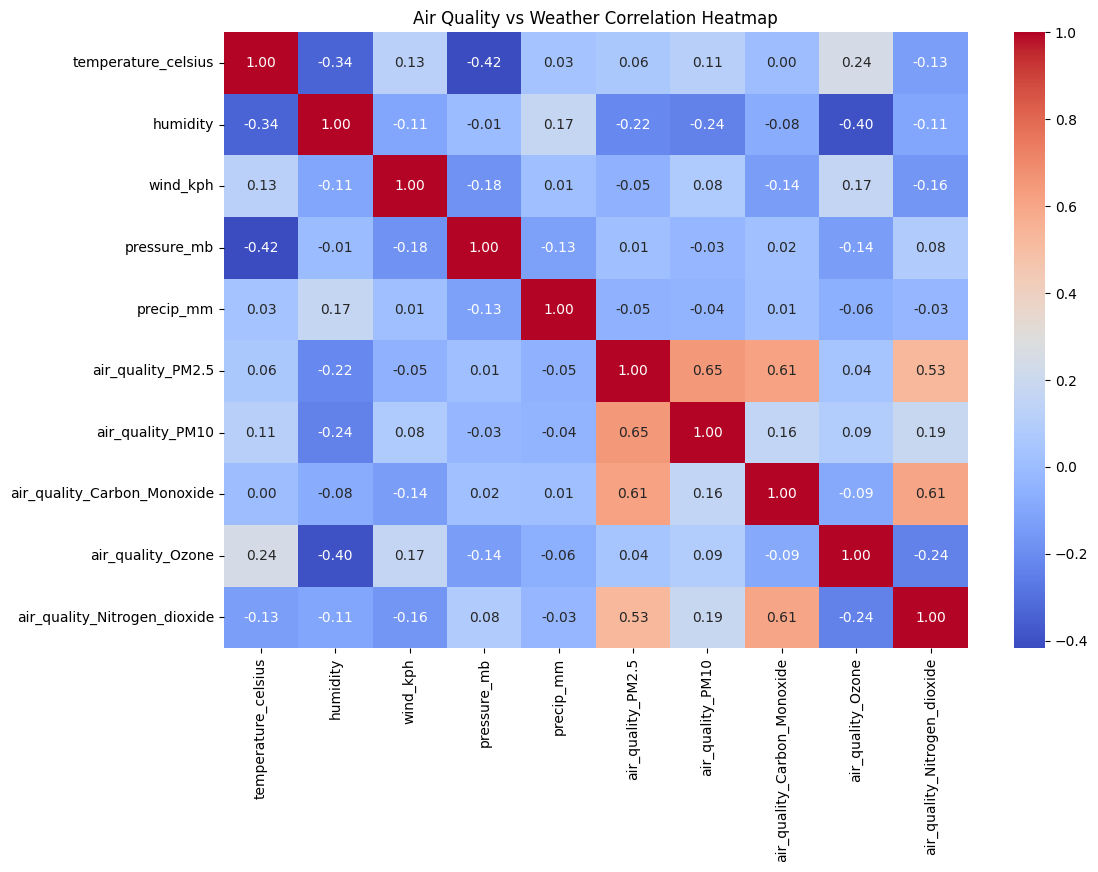

In [68]:
aq_cols = [
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'pressure_mb',
    'precip_mm',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide'
]

aq_df = df_cleaned[aq_cols].copy()

aq_df.head()

plt.figure(figsize=(12,8))

corr = aq_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Air Quality vs Weather Correlation Heatmap")

plt.show()

The correlation analysis reveals relationships between air quality indicators and meteorological variables. Pollutants such as PM2.5 and PM10 show varying degrees of association with humidity, wind speed, and atmospheric pressure, indicating that weather conditions influence pollutant dispersion and concentration levels.

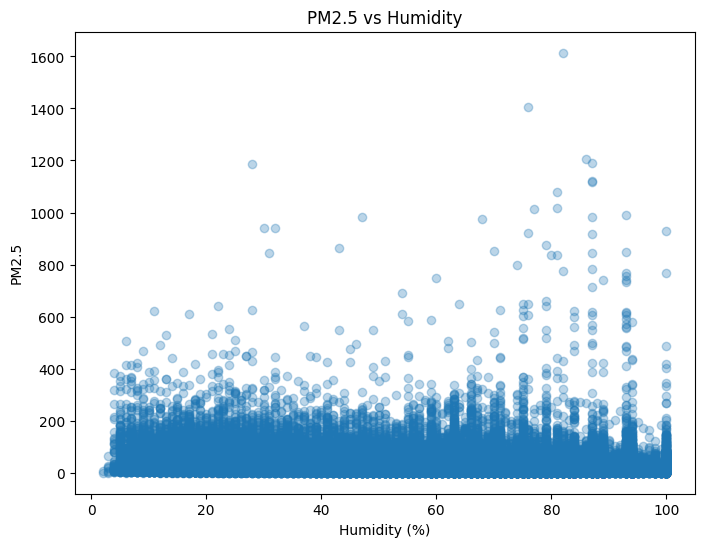

In [69]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_cleaned['humidity'],
    df_cleaned['air_quality_PM2.5'],
    alpha=0.3
)

plt.title("PM2.5 vs Humidity")
plt.xlabel("Humidity (%)")
plt.ylabel("PM2.5")

plt.show()

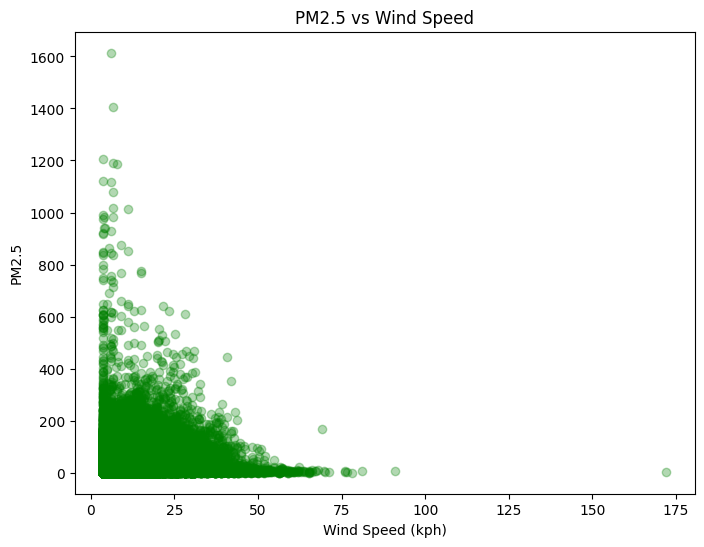

In [70]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_cleaned['wind_kph'],
    df_cleaned['air_quality_PM2.5'],
    alpha=0.3,
    color='green'
)

plt.title("PM2.5 vs Wind Speed")
plt.xlabel("Wind Speed (kph)")
plt.ylabel("PM2.5")

plt.show()

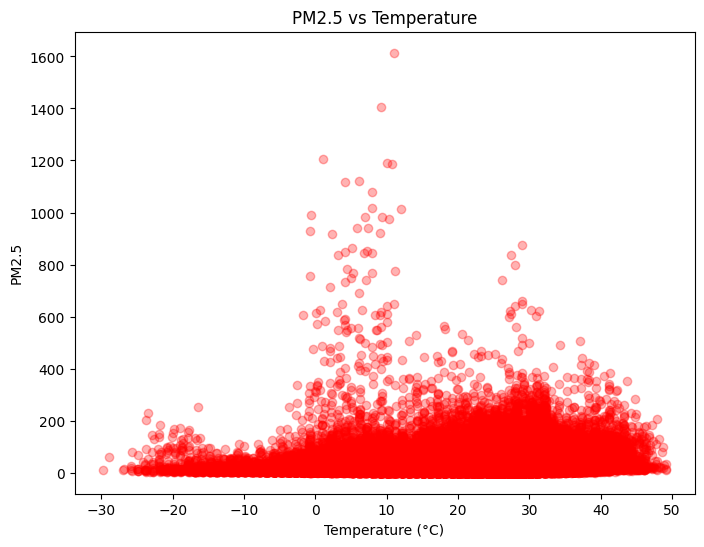

In [71]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_cleaned['temperature_celsius'],
    df_cleaned['air_quality_PM2.5'],
    alpha=0.3,
    color='red'
)

plt.title("PM2.5 vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5")

plt.show()

Air quality analysis shows that particulate matter (PM2.5 and PM10) exhibits weak to moderate correlations with weather conditions such as humidity, wind speed, and temperature. Higher wind speeds generally contribute to lower pollution concentration due to dispersion effects, while higher humidity may be associated with increased particulate accumulation. These relationships highlight the interaction between atmospheric conditions and pollutant behavior.

### 3. Feature Importance 

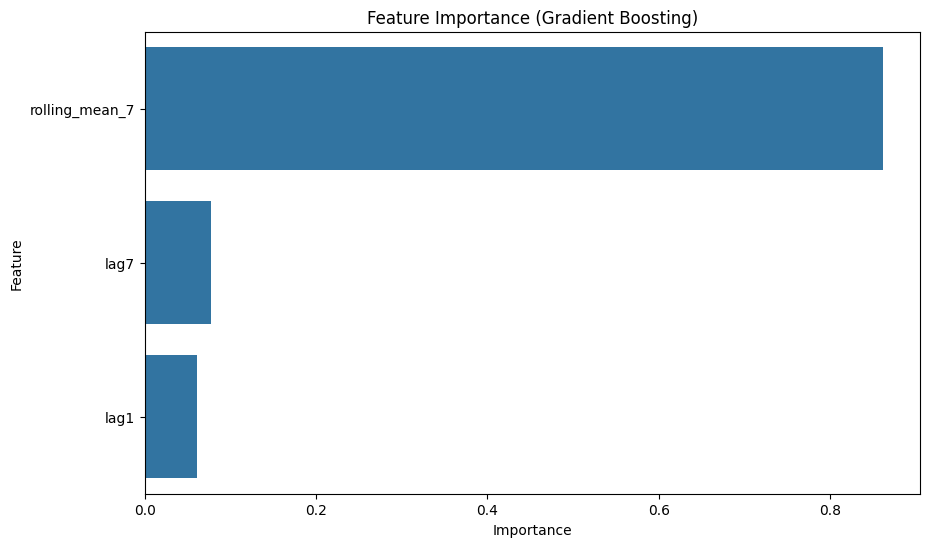

In [73]:
# gradient boosting 

features = X_train.columns
importances = gb_model.feature_importances_

feat_imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feat_imp_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Gradient Boosting)")
plt.show()


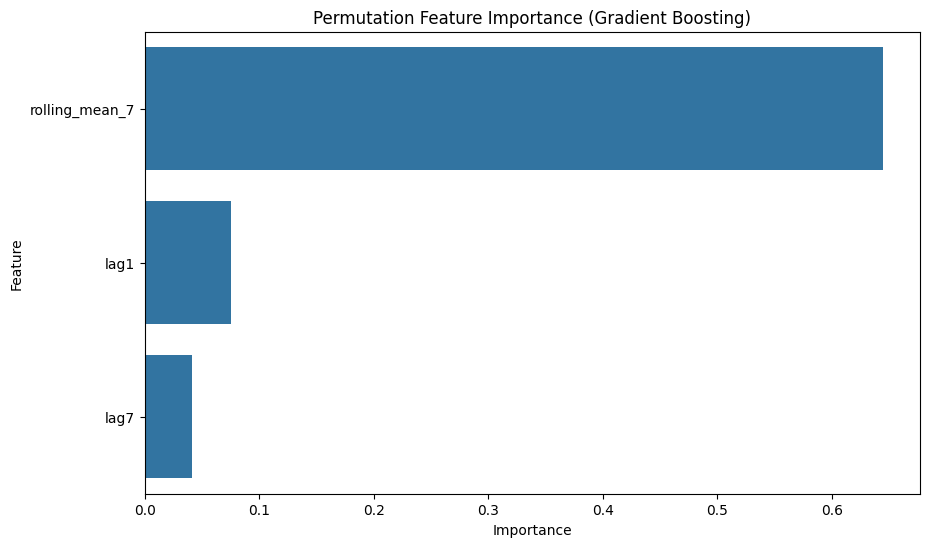

In [76]:
# permutation importance 

perm_importance = permutation_importance(
    gb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=perm_df,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance (Gradient Boosting)")
plt.show()

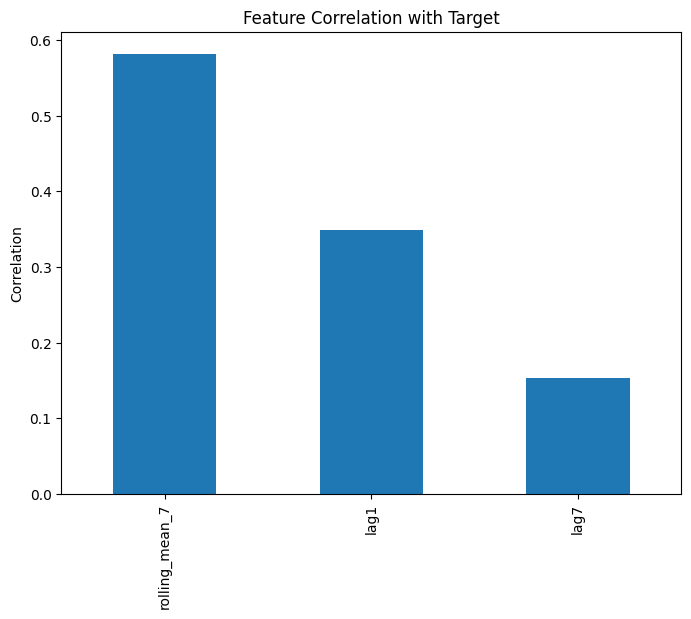

In [ ]:
# correlation based

corr = pd.concat([X_train, y_train], axis=1).corr()

target_corr = corr[y_train.name].sort_values(ascending=False)

plt.figure(figsize=(8,6))

target_corr.drop(y_train.name).plot(kind='bar')

plt.title("Feature Correlation with Target")
plt.ylabel("Correlation")

plt.show()

Feature importance is analyzed using multiple techniques, including tree based importance from Gradient Boosting, permutation importance and correlation analysis. Tree-based methods identify features used most frequently in decision splits, while permutation importance evaluates the impact of each feature on model performance. Correlation analysis provides additional insight into linear relationships between predictors and the target variable. Across all methods, lag-based temporal features and weather variables such as humidity and pressure showed the highest predictive influence.

### 4. Spatial analysis

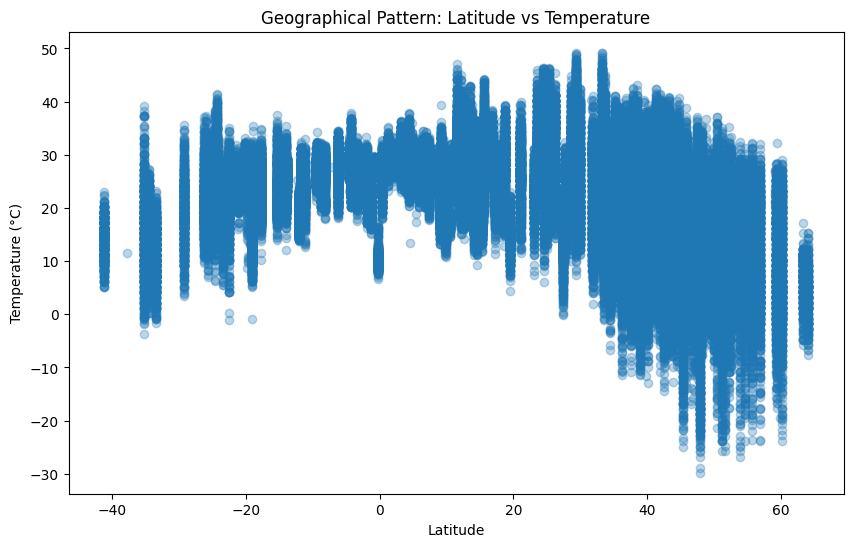

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df_cleaned['latitude'],
    df_cleaned['temperature_celsius'],
    alpha=0.3
)

plt.title("Geographical Pattern: Latitude vs Temperature")
plt.xlabel("Latitude")
plt.ylabel("Temperature (°C)")

plt.show()

Temperature shows a clear geographical dependency on latitude, where regions closer to the equator exhibit higher temperatures, while higher latitudes tend to be cooler. This confirms expected global climate distribution patterns.

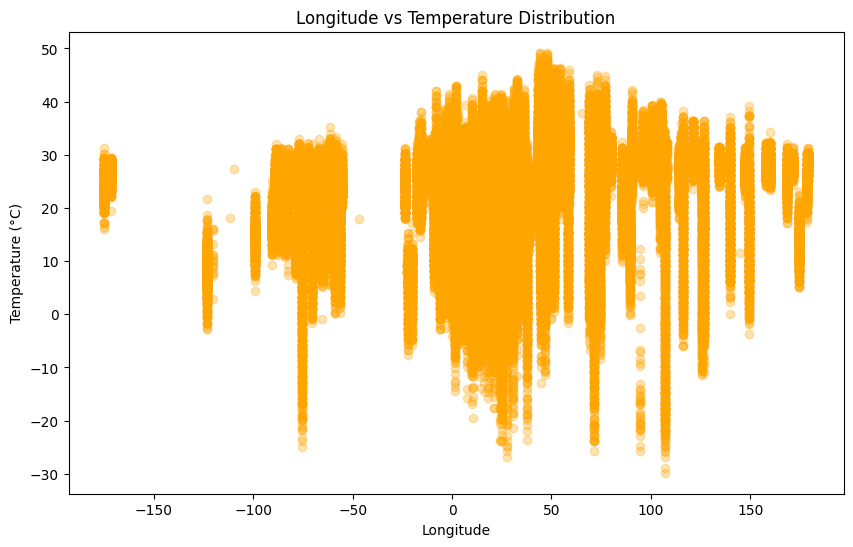

In [79]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_cleaned['longitude'],
    df_cleaned['temperature_celsius'],
    alpha=0.3,
    color='orange'
)

plt.title("Longitude vs Temperature Distribution")
plt.xlabel("Longitude")
plt.ylabel("Temperature (°C)")

plt.show()

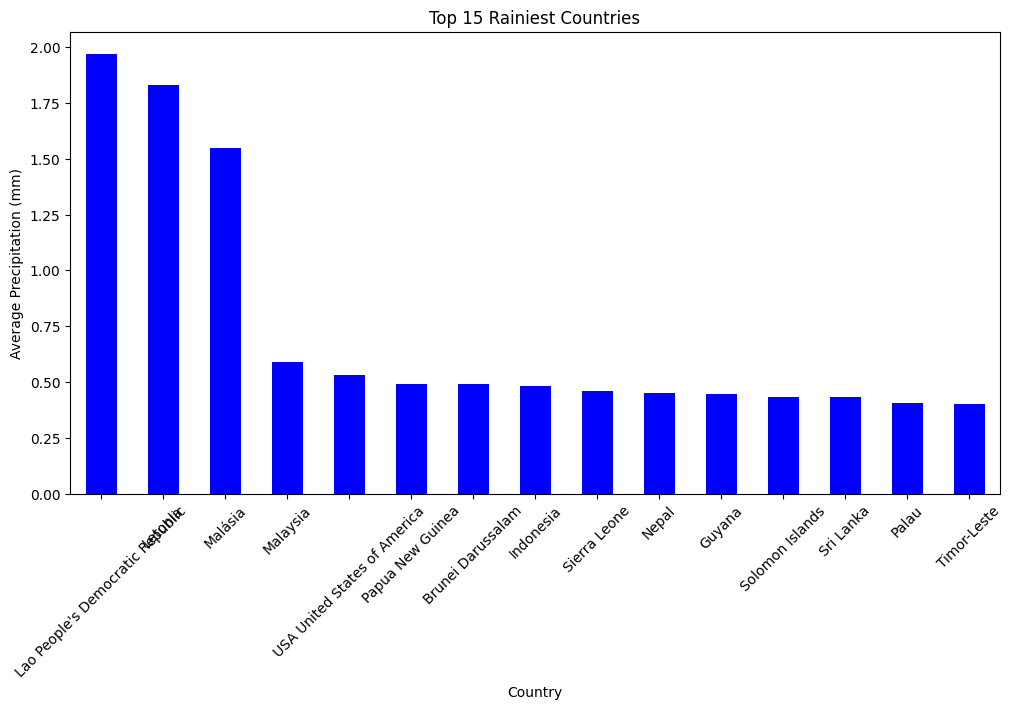

In [81]:
top_countries_rain = (
    df_cleaned.groupby('country')['precip_mm']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

top_countries_rain.plot(kind='bar', color='blue')

plt.title("Top 15 Rainiest Countries")
plt.xlabel("Country")
plt.ylabel("Average Precipitation (mm)")
plt.xticks(rotation=45)

plt.show()

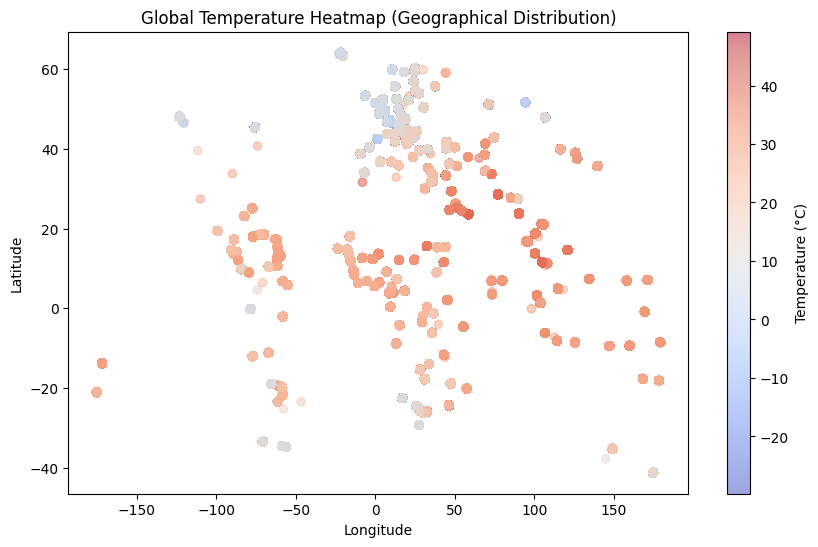

In [82]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_cleaned['longitude'],
    df_cleaned['latitude'],
    c=df_cleaned['temperature_celsius'],
    cmap='coolwarm',
    alpha=0.5
)

plt.colorbar(label="Temperature (°C)")

plt.title("Global Temperature Heatmap (Geographical Distribution)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

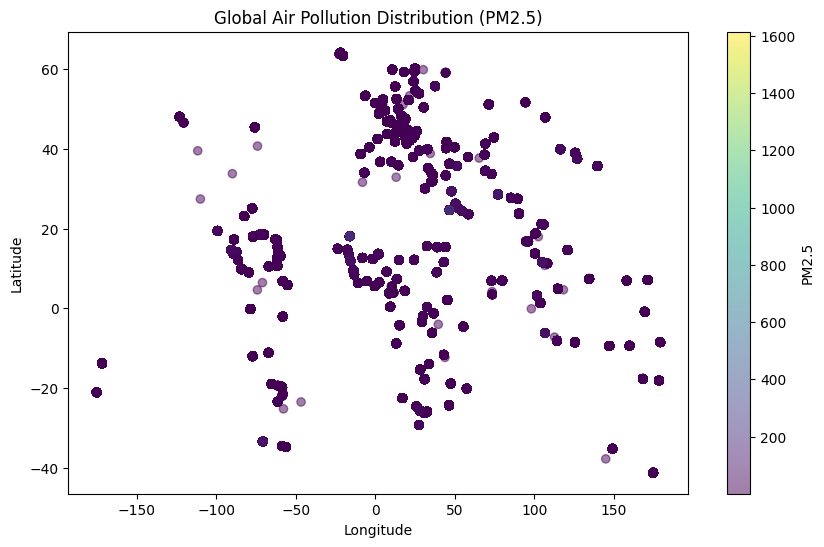

In [83]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_cleaned['longitude'],
    df_cleaned['latitude'],
    c=df_cleaned['air_quality_PM2.5'],
    cmap='viridis',
    alpha=0.5
)

plt.colorbar(label="PM2.5")

plt.title("Global Air Pollution Distribution (PM2.5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

Geographical analysis reveals strong spatial patterns in both temperature and air quality. Temperature decreases with increasing latitude, confirming global climate zoning. Additionally, air pollution levels (PM2.5) vary significantly across geographical regions, indicating regional differences in environmental and atmospheric conditions.

### 5. Geographical patterns 

In [84]:
# creating continent mapping

continent_map = {
    'Afghanistan': 'Asia', 'Albania': 'Europe', 'Algeria': 'Africa',
    'Andorra': 'Europe', 'Angola': 'Africa', 'Argentina': 'South America',
    'Australia': 'Oceania', 'Austria': 'Europe', 'Bangladesh': 'Asia',
    'Brazil': 'South America', 'Canada': 'North America',
    'China': 'Asia', 'France': 'Europe', 'Germany': 'Europe',
    'India': 'Asia', 'Indonesia': 'Asia', 'Italy': 'Europe',
    'Japan': 'Asia', 'Mexico': 'North America',
    'Nigeria': 'Africa', 'Russia': 'Europe', 'South Africa': 'Africa',
    'United Kingdom': 'Europe', 'United States': 'North America'
}

df_cleaned['continent'] = df_cleaned['country'].map(continent_map)

C:\Users\Harshitha GR\AppData\Local\Temp\ipykernel_1776\4292582309.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['continent'] = df_cleaned['country'].map(continent_map)


C:\Users\Harshitha GR\AppData\Local\Temp\ipykernel_1776\1259237098.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


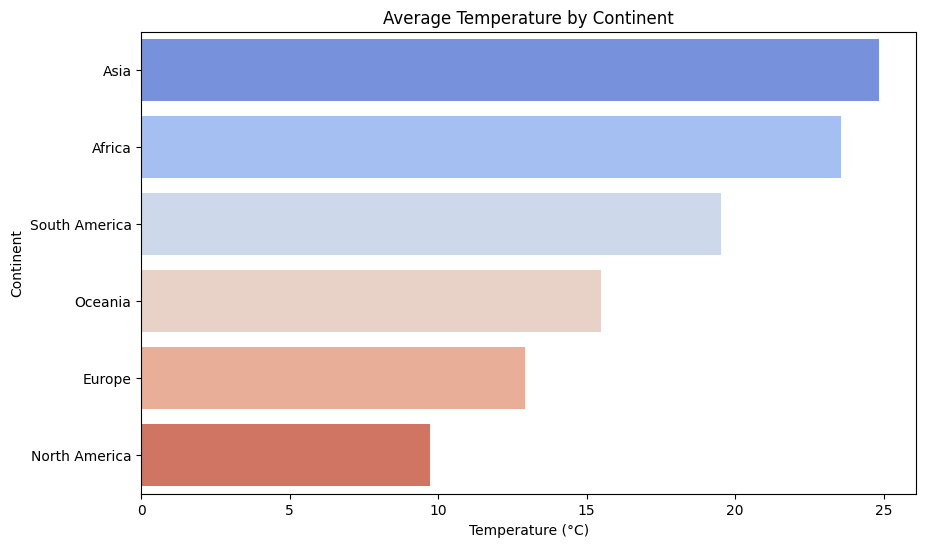

In [85]:
continent_temp = (
    df_cleaned.groupby('continent')['temperature_celsius']
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=continent_temp.values,
    y=continent_temp.index,
    palette="coolwarm"
)

plt.title("Average Temperature by Continent")
plt.xlabel("Temperature (°C)")
plt.ylabel("Continent")

plt.show()

C:\Users\Harshitha GR\AppData\Local\Temp\ipykernel_1776\458875149.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


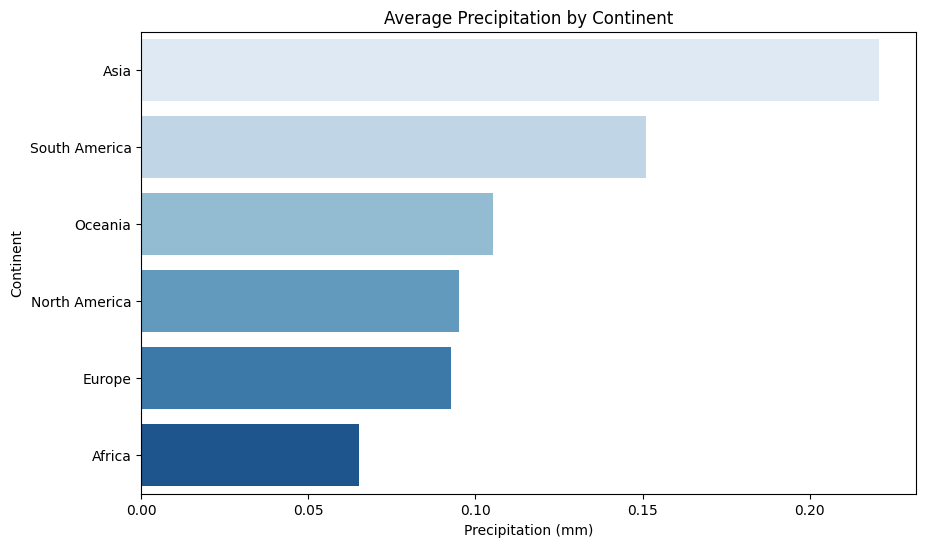

In [86]:
continent_rain = (
    df_cleaned.groupby('continent')['precip_mm']
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=continent_rain.values,
    y=continent_rain.index,
    palette="Blues"
)

plt.title("Average Precipitation by Continent")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Continent")

plt.show()

C:\Users\Harshitha GR\AppData\Local\Temp\ipykernel_1776\4278050754.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


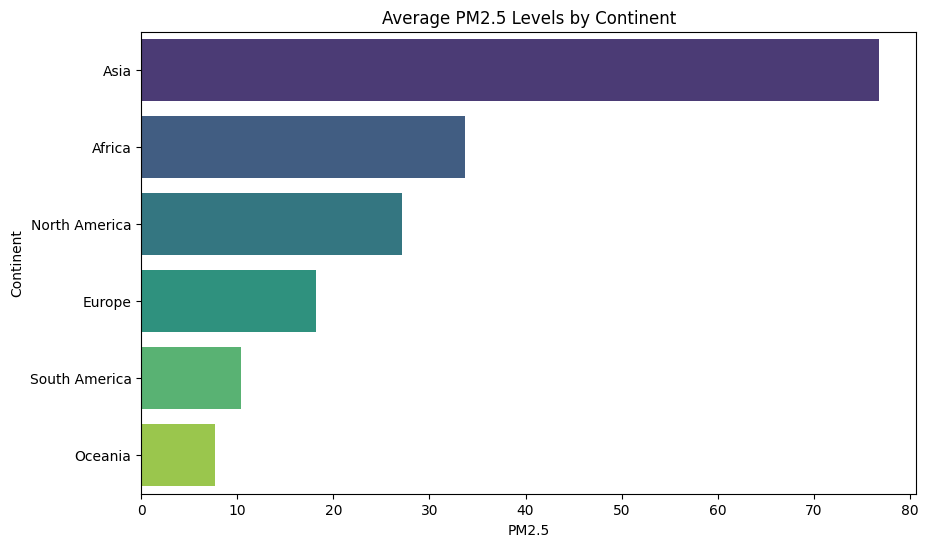

In [87]:
continent_pm = (
    df_cleaned.groupby('continent')['air_quality_PM2.5']
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=continent_pm.values,
    y=continent_pm.index,
    palette="viridis"
)

plt.title("Average PM2.5 Levels by Continent")
plt.xlabel("PM2.5")
plt.ylabel("Continent")

plt.show()

Weather conditions vary significantly across countries and continents. Tropical and equatorial regions such as Africa, South America and parts of Asia show higher average temperatures, while Europe and North America exhibit more moderate climates. Precipitation patterns also vary widely, with some continents experiencing consistently higher rainfall levels. Additionally, air quality differs across regions, with industrialized and densely populated areas showing higher PM2.5 concentrations.